# Neural Pseudogradient Ascent — Multi-Unit Auction

**Setup:**
- $n = 4$ jugadores (vendedores)
- $q = 2$ unidades por jugador → 8 bids en total
- $k = 3$ unidades demandadas
- Costos marginales: $\phi_i \sim U[0,1]$ i.i.d.
- Mecanismo: subasta discriminatoria (*pay-as-bid*) — cada unidad aceptada recibe su propio bid
- **BNE simétrico analítico:**
$$\beta(\phi) = \frac{3(\phi+1)^2}{4(\phi+2)}$$

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import random
import pickle

# ============================================================
# Reproducibilidad
# ============================================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# ============================================================
# Parámetros del juego
# ============================================================
N_PLAYERS = 4     # número de jugadores
N_UNITS   = 2     # unidades que puede ofrecer cada jugador
DEMAND    = 3     # unidades que demanda el comprador

print(f"Setup: {N_PLAYERS} jugadores | {N_UNITS} unidades/jugador | {DEMAND} unidades demandadas")
print(f"Total unidades en subasta: {N_PLAYERS * N_UNITS}")

Setup: 4 jugadores | 2 unidades/jugador | 3 unidades demandadas
Total unidades en subasta: 8


In [2]:
# ============================================================
# 1. Sampler de costos privados: phi_i ~ Uniform[0,1]
#    Cada jugador tiene UN costo marginal para sus dos unidades
# ============================================================
class BaselineSampler:
    def __init__(self, n_players):
        self.n_players = n_players

    def sample(self, batch_size):
        # c[b, i, 0] = costo del jugador i en el escenario b
        c = torch.rand(batch_size, self.n_players, 1)
        o = c   # observación = costo propio (información privada)
        return c, o

In [3]:
# ============================================================
# 2. BidderNet — red que mapea costo → bid por unidad
#    Arquitectura: 1 → 10 → 10 → 1, activación SELU
#    Garantía: bid >= costo (markup = ReLU(raw) >= 0)
#
#    Como cada jugador tiene 2 unidades con el MISMO costo,
#    ambas unidades reciben el mismo bid: beta(phi)
# ============================================================
class BidderNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 10), nn.SELU(),
            nn.Linear(10, 10), nn.SELU(),
            nn.Linear(10, 1)
        )

    def forward(self, x):
        # markup >= 0 garantiza bid >= costo
        markup = torch.relu(self.net(x))
        return x + markup   # bid = costo + markup

In [4]:
# ============================================================
# 3. Función de utilidad — subasta discriminatoria multi-unidad
#
# Mecanismo:
#   - 4 jugadores × 2 unidades = 8 bids en total
#   - Se aceptan las DEMAND=3 ofertas más bajas
#   - Cada unidad aceptada recibe su propio bid (pay-as-bid)
#   - Utilidad jugador i = unidades_ganadas × (bid_i - costo_i)
#
# Cálculo eficiente:
#   Sea n_lower = número de unidades rivales con bid < bid_i
#   Dado que los costos son continuos, ties tienen prob. 0.
#   Unidades ganadas = clamp(DEMAND - n_lower, 0, N_UNITS)
# ============================================================
def compute_utility(
    bid_i,           # (batch,) bid del jugador i (una cifra, aplica a ambas unidades)
    cost_i,          # (batch,) costo del jugador i
    opp_bids_flat,   # (batch, (N_PLAYERS-1)*N_UNITS) bids de los rivales
    demand=DEMAND,
    n_units=N_UNITS,
):
    # Cuántas unidades rivales ofrecen MENOS que bid_i
    n_lower = (opp_bids_flat < bid_i.unsqueeze(1)).float().sum(dim=1)  # (batch,)

    # Unidades ganadas por jugador i
    n_won = torch.clamp(demand - n_lower, min=0.0, max=float(n_units))  # (batch,)

    # Ganancia = unidades ganadas × markup
    util = n_won * (bid_i - cost_i)
    return util.mean()


def get_opponent_bids(policies, o_batch, i, n_players=N_PLAYERS, n_units=N_UNITS, device='cpu'):
    """Devuelve tensor (batch, (n_players-1)*n_units) con bids de todos los rivales."""
    opp = []
    for j in range(n_players):
        if j != i:
            b_j = policies[j](o_batch[:, j]).squeeze(1)          # (batch,)
            opp.append(b_j.unsqueeze(1).expand(-1, n_units))     # (batch, n_units)
    return torch.cat(opp, dim=1)  # (batch, (n_players-1)*n_units)

In [5]:
# ============================================================
# 4. Pre-entrenamiento — inicializa en bid = costo (verdad)
#    Esto estabiliza el arranque del NPGA.
# ============================================================
def pretrain_truthful(policies, sampler, device, steps=500, batch_size=2**17):
    optims = [torch.optim.SGD(pol.parameters(), lr=0.01) for pol in policies]
    print("\n>>> Pre-entrenamiento: bid = costo...\n")
    for step in range(steps):
        costs, obs = sampler.sample(batch_size)
        costs, obs = costs.to(device), obs.to(device)
        loss_val = 0.0
        for i, pol in enumerate(policies):
            optims[i].zero_grad()
            pred   = pol(obs[:, i]).squeeze()
            target = costs[:, i].squeeze()
            loss   = ((pred - target) ** 2).mean()
            loss.backward()
            optims[i].step()
            loss_val = loss.item()
        if step % 100 == 0:
            print(f"  Paso {step:4d}/{steps} — loss={loss_val:.6f}")

In [6]:
# ============================================================
# 5. NPGA con Evolution Strategies + Adam
#    Pseudogradiente ES: grad ≈ (1/2σ·pop) Σ_k (u(θ+σε) - u(θ-σε)) · ε
# ============================================================
def train_npga_multiunit(
    n_players      = N_PLAYERS,
    n_units        = N_UNITS,
    demand         = DEMAND,
    n_epochs       = 1000,
    pretrain_iters = 500,
    batch_size     = 2**17,
    pop            = 64,      # tamaño de población ES
    lr             = 0.03,
    sigma          = 0.05,    # radio de perturbación ES
    eval_frequency = 50,
    n_runs         = 10,
    eval_batch_size= 2**15,
):
    device  = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    sampler = BaselineSampler(n_players)
    print(f"\n>>> Dispositivo: {device}")

    # Grid para evaluar convergencia
    grid_np  = np.linspace(0, 1, 200)
    grid_dev = torch.tensor(grid_np, dtype=torch.float32).view(200, 1).to(device)

    # BNE analítico: beta(phi) = 3*(phi+1)^2 / (4*(phi+2))
    bne = 3 * (grid_np + 1)**2 / (4 * (grid_np + 2))

    all_results = []

    for run in range(n_runs):
        set_seed(1000 + run)
        print(f"\n{'='*32}\n  RUN {run+1}/{n_runs}\n{'='*32}")

        # Inicializar redes y optimizadores
        policies = [BidderNet().to(device) for _ in range(n_players)]
        optims   = [torch.optim.Adam(pol.parameters(), lr=lr) for pol in policies]

        # Pre-entrenamiento
        pretrain_truthful(policies, sampler, device,
                          steps=pretrain_iters, batch_size=batch_size)

        results = {k: [] for k in [
            "epoch", "mse", "util_mean", "policy_step",
            "player_dispersion", "grad_norm", "curves_mean", "curves_all"
        ]}
        prev_curves = None

        # -------------------------------------------------------
        # Bucle principal NPGA
        # -------------------------------------------------------
        for epoch in range(n_epochs):
            c_batch, o_batch = sampler.sample(batch_size)
            c_batch, o_batch = c_batch.to(device), o_batch.to(device)
            grad_norms_epoch = []

            for i in range(n_players):
                # Aplanar parámetros del jugador i
                theta_vec = torch.cat([p.data.flatten()
                                       for p in policies[i].parameters()])
                d = theta_vec.numel()
                grad_vec = torch.zeros(d, device=device)

                # --- Evolution Strategy: antithetic sampling ---
                for _ in range(pop):
                    eps = torch.randn(d, device=device)
                    u_vals = []

                    for sign in (+1, -1):
                        theta_pert = theta_vec + sign * sigma * eps

                        # Crear red perturbada
                        pert = BidderNet().to(device)
                        offset = 0
                        for p in pert.parameters():
                            sz = p.numel()
                            p.data = theta_pert[offset:offset+sz].view_as(p)
                            offset += sz

                        with torch.no_grad():
                            bid_i = pert(o_batch[:, i]).squeeze(1)   # (batch,)
                            opp_flat = get_opponent_bids(
                                policies, o_batch, i,
                                n_players, n_units, device
                            )
                            u = compute_utility(
                                bid_i, c_batch[:, i].squeeze(1),
                                opp_flat, demand, n_units
                            )
                        u_vals.append(u)

                    # Acumular pseudogradiente ES
                    grad_vec += (u_vals[0] - u_vals[1]) * eps

                grad_vec /= (2 * pop * sigma)
                grad_norms_epoch.append(torch.norm(grad_vec).item())

                # Paso de ascenso: Adam maximiza utilidad
                optims[i].zero_grad()
                offset = 0
                for p in policies[i].parameters():
                    sz = p.numel()
                    p.grad = -grad_vec[offset:offset+sz].view_as(p)  # negativo = ascenso
                    offset += sz
                optims[i].step()

            # -------------------------------------------------------
            # Evaluación periódica
            # -------------------------------------------------------
            if epoch % eval_frequency == 0 or epoch == n_epochs - 1:
                with torch.no_grad():
                    # Curvas de bid por jugador en el grid [0,1]
                    player_curves = np.array([
                        policies[j](grid_dev).cpu().numpy().squeeze()
                        for j in range(n_players)
                    ])  # (n_players, 200)

                    mean_curve = player_curves.mean(axis=0)
                    mse        = float(np.mean((mean_curve - bne)**2))
                    dispersion = float(np.mean((player_curves - mean_curve[None,:])**2))
                    step_dist  = float(np.nan) if prev_curves is None else \
                                 float(np.mean((player_curves - prev_curves)**2))
                    prev_curves = player_curves.copy()

                    # Utilidad media en batch fresco
                    c_ev, o_ev = sampler.sample(eval_batch_size)
                    c_ev, o_ev = c_ev.to(device), o_ev.to(device)
                    utils = []
                    for j in range(n_players):
                        b_j = policies[j](o_ev[:, j]).squeeze(1)
                        opp = get_opponent_bids(policies, o_ev, j,
                                                n_players, n_units, device)
                        utils.append(
                            compute_utility(
                                b_j, c_ev[:, j].squeeze(1),
                                opp, demand, n_units
                            ).item()
                        )
                    util_mean     = float(np.mean(utils))
                    grad_norm_mean= float(np.mean(grad_norms_epoch))

                for key, val in zip(
                    ["epoch","mse","util_mean","policy_step",
                     "player_dispersion","grad_norm","curves_mean","curves_all"],
                    [epoch, mse, util_mean, step_dist,
                     dispersion, grad_norm_mean, mean_curve, player_curves]
                ):
                    results[key].append(val)

                print(
                    f"[Epoch {epoch:4d}] "
                    f"MSE={mse:.6f} | "
                    f"Util={util_mean:.6f} | "
                    f"Step={step_dist:.4e} | "
                    f"Disp={dispersion:.4e} | "
                    f"GradNorm={grad_norm_mean:.4e}"
                )

        all_results.append(results)

    print("\n>>> Entrenamiento terminado.")
    return all_results, grid_np, bne

In [7]:
# ============================================================
# 6. EJECUTAR
# ============================================================
results, vals, bne = train_npga_multiunit(
    n_players      = 4,
    n_units        = 2,
    demand         = 3,
    n_epochs       = 1000,
    pretrain_iters = 500,
    batch_size     = 2**17,
    pop            = 64,
    lr             = 0.03,
    sigma          = 0.05,
    eval_frequency = 200,
    n_runs         = 10,
    eval_batch_size= 2**15,
)


>>> Dispositivo: cuda

  RUN 1/10

>>> Pre-entrenamiento: bid = costo...

  Paso    0/500 — loss=0.000000
  Paso  100/500 — loss=0.000000
  Paso  200/500 — loss=0.000000
  Paso  300/500 — loss=0.000000
  Paso  400/500 — loss=0.000000
[Epoch    0] MSE=0.013254 | Util=0.057903 | Step=nan | Disp=1.4947e-02 | GradNorm=5.5391e-01
[Epoch  200] MSE=0.001371 | Util=0.233765 | Step=3.4839e-02 | Disp=1.1399e-04 | GradNorm=4.1191e-01
[Epoch  400] MSE=0.003302 | Util=0.245899 | Step=1.8500e-03 | Disp=1.1558e-03 | GradNorm=1.4313e+00
[Epoch  600] MSE=0.001493 | Util=0.231146 | Step=2.5808e-03 | Disp=8.0037e-04 | GradNorm=8.2256e-01
[Epoch  800] MSE=0.002937 | Util=0.143497 | Step=3.0399e-02 | Disp=2.9813e-02 | GradNorm=6.1588e-01
[Epoch  999] MSE=0.004871 | Util=0.154596 | Step=3.7716e-02 | Disp=5.0979e-04 | GradNorm=5.1974e-01

  RUN 2/10

>>> Pre-entrenamiento: bid = costo...

  Paso    0/500 — loss=0.047498
  Paso  100/500 — loss=0.000000
  Paso  200/500 — loss=0.000000
  Paso  300/500 — loss=0

In [8]:
# ============================================================
# 7. Guardar resultados
# ============================================================
with open("results_npga_multiunit.pkl", "wb") as f:
    pickle.dump({"results": results, "vals": vals, "bne": bne}, f)
print("Resultados guardados en results_npga_multiunit.pkl")

Resultados guardados en results_npga_multiunit.pkl


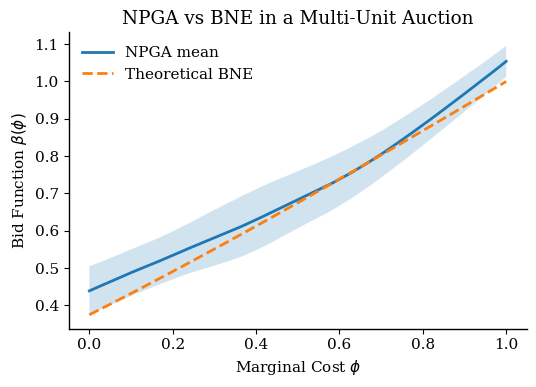

In [15]:
# ============================================================
# 8. GRÁFICA: Curva aprendida vs BNE analítico
#    beta(phi) = 3*(phi+1)^2 / (4*(phi+2))
# ============================================================
plt.rcParams.update({
    "font.size": 11, "font.family": "serif",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.linewidth": 1.0, "legend.frameon": False,
})

all_final = np.array([r["curves_mean"][-1] for r in results])
mean_curve = all_final.mean(axis=0)
std_curve  = all_final.std(axis=0)

fig, ax = plt.subplots(figsize=(5.5, 4))

ax.plot(vals, mean_curve, lw=2, label="NPGA mean")
ax.fill_between(vals,
                mean_curve - std_curve,
                mean_curve + std_curve, alpha=0.20)
ax.plot(vals, bne, "--", lw=2,
        label=r"Theoretical BNE")
#ax.plot([0,1],[0,1], ":", color="gray", lw=1, label="bid = marginal cost")

ax.set_xlabel(r"Marginal Cost $\phi$")
ax.set_ylabel(r"Bid Function $\beta(\phi)$")
ax.set_title("NPGA vs BNE in a Multi-Unit Auction")
             #r"$N=4,\ g=2,\ D=3,\ \phi\sim U[0,1]$")
ax.legend()
plt.tight_layout()
plt.savefig("npga_multiunit_bne.png", dpi=150, bbox_inches="tight")
plt.show()

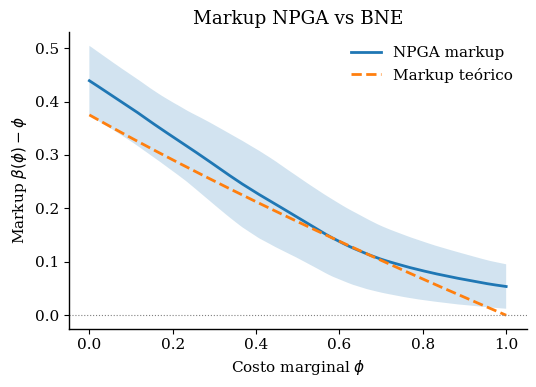

In [10]:
# ============================================================
# 9. GRÁFICA: Markup aprendido vs teórico
#    markup = beta(phi) - phi
# ============================================================
markup_npga = mean_curve - vals
markup_bne  = bne - vals

fig, ax = plt.subplots(figsize=(5.5, 4))
ax.plot(vals, markup_npga, lw=2, label="NPGA markup")
ax.fill_between(vals,
                markup_npga - std_curve,
                markup_npga + std_curve, alpha=0.20)
ax.plot(vals, markup_bne, "--", lw=2, label="Markup teórico")
ax.axhline(0, color="gray", lw=0.8, ls=":")

ax.set_xlabel(r"Costo marginal $\phi$")
ax.set_ylabel(r"Markup $\beta(\phi) - \phi$")
ax.set_title("Markup NPGA vs BNE")
ax.legend()
plt.tight_layout()
plt.savefig("npga_multiunit_markup.png", dpi=150, bbox_inches="tight")
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_24452\358459892.py:12: RuntimeWarning: Mean of empty slice
  m = np.nanmean(Y, axis=0)
c:\Users\HP\Documents\GitHub\TesisPEG\gpu_env_cuda\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


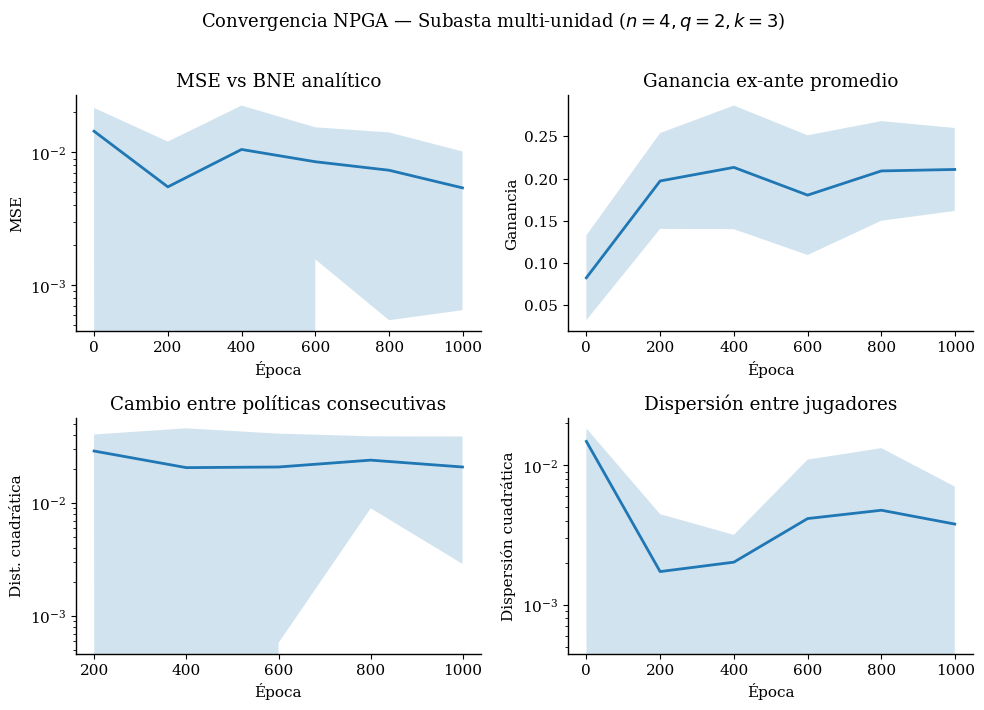

In [11]:
# ============================================================
# 10. GRÁFICA: Métricas de convergencia (4 paneles)
# ============================================================
epochs    = np.array(results[0]["epoch"])
all_mse   = np.array([r["mse"]               for r in results])
all_util  = np.array([r["util_mean"]          for r in results])
all_step  = np.array([r["policy_step"]        for r in results])
all_disp  = np.array([r["player_dispersion"]  for r in results])
all_grad  = np.array([r["grad_norm"]          for r in results])

def plot_band(ax, x, Y, title, ylabel, logy=False):
    m = np.nanmean(Y, axis=0)
    s = np.nanstd(Y,  axis=0)
    ax.plot(x, m, lw=2)
    ax.fill_between(x, m - s, m + s, alpha=0.2)
    ax.set_title(title);  ax.set_xlabel("Época");  ax.set_ylabel(ylabel)
    if logy: ax.set_yscale("log")

fig, axs = plt.subplots(2, 2, figsize=(10, 7))
plot_band(axs[0,0], epochs, all_mse,
          "MSE vs BNE analítico", "MSE", logy=True)
plot_band(axs[0,1], epochs, all_util,
          "Ganancia ex-ante promedio", "Ganancia")
plot_band(axs[1,0], epochs, all_step,
          "Cambio entre políticas consecutivas", "Dist. cuadrática", logy=True)
plot_band(axs[1,1], epochs, all_disp,
          "Dispersión entre jugadores", "Dispersión cuadrática", logy=True)

plt.suptitle("Convergencia NPGA — Subasta multi-unidad ($n=4, q=2, k=3$)",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("npga_multiunit_convergence.png", dpi=150, bbox_inches="tight")
plt.show()

In [28]:
import numpy as np
all_mse_sel = np.delete(all_mse, [1, 3,9], axis=0)  # eliminar runs 1, 3 y 9 (ejemplos de convergencia pobre)

In [32]:
all_mse

array([[0.01325374, 0.00137144, 0.00330171, 0.00149317, 0.00293699,
        0.00487073],
       [0.01891873, 0.02304182, 0.01359289, 0.02066558, 0.01103519,
        0.0024123 ],
       [0.00776017, 0.00451117, 0.00451624, 0.0198446 , 0.00202324,
        0.00269728],
       [0.0227016 , 0.01184514, 0.02593349, 0.00362278, 0.02092068,
        0.01019624],
       [0.01518174, 0.00167801, 0.00834664, 0.00856675, 0.00227121,
        0.00118292],
       [0.0083301 , 0.00288295, 0.00270323, 0.00949651, 0.00460437,
        0.01748632],
       [0.02920423, 0.00389439, 0.00624753, 0.00195445, 0.0102684 ,
        0.00477771],
       [0.01445093, 0.00050684, 0.0002751 , 0.00340504, 0.00218188,
        0.00639497],
       [0.00361793, 0.00188694, 0.03929502, 0.00245251, 0.00010114,
        0.00189047],
       [0.01105188, 0.00348837, 0.00113936, 0.01365588, 0.01715076,
        0.00224569]])

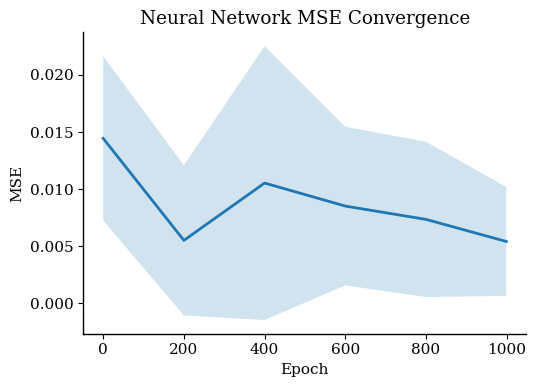

In [36]:
# ============================================================
# 11. GRÁFICA: Convergencia del error (primeras 5 épocas de eval)
# ============================================================
epochs_5   = epochs[:6]
mean_mse_5 = all_mse.mean(axis=0)[:6]
std_mse_5  = all_mse.std(axis=0)[:6]

fig, ax = plt.subplots(figsize=(5.5, 4))
ax.plot(epochs_5, mean_mse_5, lw=2, label="NPGA MSE")
ax.fill_between(epochs_5,
                mean_mse_5 - std_mse_5,
                mean_mse_5 + std_mse_5, alpha=0.2)
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE")
ax.set_title("Neural Network MSE Convergence")
plt.tight_layout()
plt.savefig("npga_multiunit_errorconvergence.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Notas teóricas

### Mecanismo
Subasta de aprovisionamiento (*procurement*) discriminatoria (pay-as-bid):
- El comprador demanda $k=3$ unidades.
- Cada vendedor $i$ con costo $\phi_i \sim U[0,1]$ oferta bid $b_i \geq \phi_i$ para cada una de sus 2 unidades.
- Se aceptan las 3 ofertas más bajas del total de 8 bids.
- Cada unidad aceptada recibe exactamente su bid.

### Función de utilidad
$$u_i(\phi_i, b_i) = q_i^*(b_i, \mathbf{b}_{-i}) \cdot (b_i - \phi_i)$$
donde $q_i^* = \#\{$unidades de $i$ aceptadas$\} \in \{0,1,2\}$.

### BNE simétrico
$$\beta(\phi) = \frac{3(\phi+1)^2}{4(\phi+2)}$$

Verificación: $\beta(0) = \frac{3}{8} = 0.375$, $\beta(1) = \frac{12}{12} = 1$ ✓

### Pseudogradiente ES
$$\hat{\nabla}_\theta U_i \approx \frac{1}{2 \sigma \cdot M} \sum_{k=1}^{M} \left[U_i(\theta+\sigma\varepsilon_k) - U_i(\theta-\sigma\varepsilon_k)\right] \varepsilon_k$$